In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from pathlib import Path
base_dir = Path().resolve().parent
data_dir = base_dir / "data"
df = pd.read_csv(data_dir / "telco_customer_churn_clean.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [3]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
df.isna().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [6]:
df.dropna(inplace=True)

In [7]:
df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-null   str    
 17  PaymentMeth

In [8]:
df.drop(columns=["customerID"], inplace=True)
X = df.drop(columns=["Churn"])
y = df["Churn"]
X_train_init, X_test, y_train_init, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

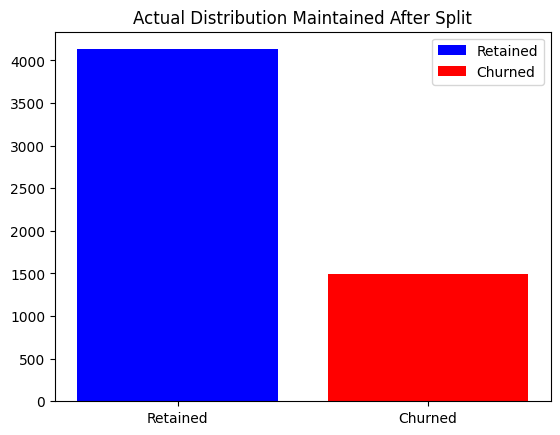

In [10]:
plt.bar(data=y_train_init,x=y_train_init.unique(), height=y_train_init.value_counts(),
       color=["b","r"], label=["Retained", "Churned"], tick_label=["Retained","Churned"])
plt.title("Actual Distribution Maintained After Split")
plt.legend()
plt.savefig(base_dir / "assets"/ "class_imbalance.png")
plt.show()

In [11]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder, StandardScaler
# one hot encoder
ohe = OneHotEncoder(
    handle_unknown="error",
    sparse_output=False
).set_output(transform="pandas")
# ordinal encoder
oe = OrdinalEncoder(
    handle_unknown="error"
).set_output(transform="pandas")
# label encoder
le = LabelEncoder()
# standard scaler
ss = StandardScaler().set_output(transform="pandas")
# adjusting the classes in each feature
for col in X_train_init.columns.tolist():
    if col in ["OnlineSecurity", "OnlineBackup",
               "DeviceProtection", "TechSupport", "StreamingTV",
               "StreamingMovies"]:
        X_train_init[col] = X_train_init[col].apply(lambda x: "No" if x=="No internet service" else x)
    elif col=="MultipleLines":
        X_train_init[col] = X_train_init[col].apply(lambda x: "No" if x=="No phone service" else x)
# creating list to separate data types
categorical_columns = []
numerical_columns = []
# running a for loop to append the lists
for col in X_train_init.columns.tolist():
    if col=="SeniorCitizen":
        continue
    elif X_train_init[col].dtype=="str":
        categorical_columns.append(col)
    else:
        numerical_columns.append(col)

In [12]:
# columns to be one hot encoded
OneHot = ["InternetService", "Contract", "PaymentMethod"]

# columns to be ordinally encoded
# Note: Even though some columns here are nominal, they are binary, and can be encoded as ordinal
Ordinal = [col for col in categorical_columns if col not in OneHot]

X_train = X_train_init[["SeniorCitizen"]]

for col in X_train_init.columns.tolist():
    if col in OneHot:
        interim = ohe.fit_transform(X_train_init[[col]])
        X_train = pd.concat([X_train, interim], axis=1)
    elif col in Ordinal:
        interim = oe.fit_transform(X_train_init[[col]])
        X_train = pd.concat([X_train, interim], axis=1)
    elif col in numerical_columns:
        interim = ss.fit_transform(X_train_init[[col]])
        X_train = pd.concat([X_train, interim], axis=1)
    elif col=="SeniorCitizen":
        X_train[col] = X_train[col].astype("float64")
    else:
        print(f"Error encoding column : {col}")

X_train.drop(columns=["InternetService_No", "Contract_Two year",
                      "PaymentMethod_Mailed check"],inplace=True)

y_train_interim = le.fit_transform(y_train_init)

y_train = pd.Series(
    data=y_train_interim,
)

In [13]:
C_vals = [0.01, 0.03, 0.09, 0.3, 0.9, 3, 9]
cof = {}
iteration = 1
for c in C_vals:
    print(f"C Value number {iteration} : C Value = {C_vals[iteration-1]}")
    feature_val = LogisticRegression(
        solver="liblinear",
        penalty="l1",
        C = c,
        l1_ratio=1.0
    )
    feature_val.fit(X_train,y_train)
    cof[c]=feature_val.coef_
    print(f"For C Value number {iteration}, training is complete")
    iteration += 1

C Value number 1 : C Value = 0.01
For C Value number 1, training is complete
C Value number 2 : C Value = 0.03
For C Value number 2, training is complete
C Value number 3 : C Value = 0.09
For C Value number 3, training is complete
C Value number 4 : C Value = 0.3
For C Value number 4, training is complete
C Value number 5 : C Value = 0.9
For C Value number 5, training is complete
C Value number 6 : C Value = 3
For C Value number 6, training is complete
C Value number 7 : C Value = 9
For C Value number 7, training is complete


In [14]:
import numpy as np
coeff_zeros = np.zeros((23,7))
coeff_df = pd.DataFrame(coeff_zeros,index=X_train.columns.to_list(),columns=C_vals)

for i,j in cof.items():
    coeff_df[i] = j[0]

coeff_df.to_csv(data_dir / "coeff_before_drop.csv")
coeff_df

,0.01,0.03,0.09,0.30,0.90,3.00,9.00
SeniorCitizen,0.000000,0.014909,0.137317,0.176443,0.187125,0.190884,0.192451
gender,0.000000,0.000000,0.000000,-0.016457,-0.023014,-0.024351,-0.023121
Partner,0.000000,0.000000,-0.005009,-0.017278,-0.020484,-0.022548,-0.024991
Dependents,-0.065133,-0.205025,-0.238172,-0.234518,-0.232207,-0.230967,-0.229848
tenure,-0.900178,-0.842321,-0.917103,-1.227828,-1.337715,-1.383108,-1.401261
PhoneService,-0.589357,-0.922944,-1.073662,-1.178216,-1.116718,-0.659801,0.024788
MultipleLines,0.000000,0.000000,0.071818,0.131576,0.170778,0.289817,0.463721
InternetService_DSL,0.000000,-0.020511,-0.036652,0.000000,0.147946,0.773246,1.647463
InternetService_Fiber optic,0.000000,0.000000,0.000000,0.071052,0.337879,1.529275,3.263601
OnlineSecurity,-0.296565,-0.481217,-0.539861,-0.563370,-0.549989,-0.443229,-0.272985


In [15]:
X_train.drop(columns="TotalCharges",inplace=True)
cof = {}
iteration = 1
for c in C_vals:
    print(f"C Value number {iteration} : C Value = {C_vals[iteration-1]}")
    feature_val = LogisticRegression(
        solver="liblinear",
        penalty="l1",
        C = c,
        l1_ratio=1.0
    )
    feature_val.fit(X_train,y_train)
    cof[c]=feature_val.coef_
    print(f"For C Value number {iteration}, training is complete")
    iteration += 1
coeff_zeros = np.zeros((22,7))
coeff_df = pd.DataFrame(coeff_zeros,index=X_train.columns.to_list(),columns=C_vals)

for i,j in cof.items():
    coeff_df[i] = j[0]

coeff_df.to_csv(data_dir / "coeff_after_one_drop.csv")
coeff_df

C Value number 1 : C Value = 0.01
For C Value number 1, training is complete
C Value number 2 : C Value = 0.03
For C Value number 2, training is complete
C Value number 3 : C Value = 0.09
For C Value number 3, training is complete
C Value number 4 : C Value = 0.3
For C Value number 4, training is complete
C Value number 5 : C Value = 0.9
For C Value number 5, training is complete
C Value number 6 : C Value = 3
For C Value number 6, training is complete
C Value number 7 : C Value = 9
For C Value number 7, training is complete


,0.01,0.03,0.09,0.30,0.90,3.00,9.00
SeniorCitizen,0.000000,0.014976,0.136770,0.175541,0.186140,0.190003,0.191607
gender,0.000000,0.000000,0.000000,-0.014476,-0.020899,-0.021734,-0.020856
Partner,0.000000,0.000000,-0.005617,-0.019623,-0.023787,-0.026363,-0.028487
Dependents,-0.065103,-0.204957,-0.239915,-0.243862,-0.244578,-0.244132,-0.243562
tenure,-0.900150,-0.842255,-0.839614,-0.819173,-0.810300,-0.805451,-0.805955
PhoneService,-0.589259,-0.922781,-1.069065,-1.110901,-1.128629,-0.523010,0.064556
MultipleLines,0.000000,0.000000,0.075143,0.157899,0.181563,0.338396,0.488543
InternetService_DSL,0.000000,-0.020516,-0.042797,0.000000,0.002443,0.799669,1.547457
InternetService_Fiber optic,0.000000,0.000000,0.000000,0.132989,0.160514,1.706215,3.192514
OnlineSecurity,-0.296543,-0.481098,-0.537338,-0.543253,-0.544573,-0.400860,-0.255004
